<a href="https://colab.research.google.com/github/MidhulaMS/EV-Population-Prediction/blob/main/EV_Population_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# For evaluating Mode
from statistics import mode
# Mutual Information: Target is salary which is continous
from sklearn.feature_selection import mutual_info_regression
# For min max scaling
from sklearn.preprocessing import MinMaxScaler



# Reading Data

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
filepath = "/content/drive/MyDrive/ICT/Project Work/export (1).csv"

In [11]:
EV_df = pd.read_csv(filepath)

## Exploratory data analysis (EDA)


In [12]:
EV_df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10


In [13]:
EV_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287763 entries, 0 to 287762
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         287763 non-null  object 
 1   County                                             287754 non-null  object 
 2   City                                               287754 non-null  object 
 3   State                                              287763 non-null  object 
 4   Postal Code                                        287754 non-null  float64
 5   Model Year                                         287763 non-null  int64  
 6   Make                                               287763 non-null  object 
 7   Model                                              287763 non-null  object 
 8   Electric Vehicle Type                              287763 non-null  object

In [14]:
EV_df.dtypes

,0
VIN (1-10),object
County,object
City,object
State,object
Postal Code,float64
Model Year,int64
Make,object
Model,object
Electric Vehicle Type,object
Clean Alternative Fuel Vehicle (CAFV) Eligibility,object


### finding missing values

In [15]:
EV_df.isnull().sum()

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


### finding duplicates

In [16]:
 EV_df.duplicated().sum()

np.int64(0)

### Data Description

In [17]:
EV_df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,287754.000000,287763.000000,287754.000000,287023.000000,2.877630e+05,2.877540e+05
mean,98174.889729,2022.207299,37.828697,28.849608,2.486886e+08,5.296750e+10
std,2638.364484,3.075325,77.223589,14.889125,6.293818e+07,1.691737e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.258425e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.658514e+08,5.303303e+10
75%,98387.000000,2024.000000,32.000000,42.000000,2.820231e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


## Univariate Analysis :analyze and understand the distribution, characteristics, and patterns of a single variable in a dataset

In [22]:
#for numerical columns
num_cols = EV_df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['Postal Code', 'Model Year', 'Electric Range', 'Legislative District',
       'DOL Vehicle ID', '2020 Census Tract'],
      dtype='object')


In [23]:
#for categorical columns
cat_cols = EV_df.select_dtypes(include='object').columns

print(cat_cols)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model',
       'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Location',
       'Electric Utility'],
      dtype='object')


### Correlation Matrix

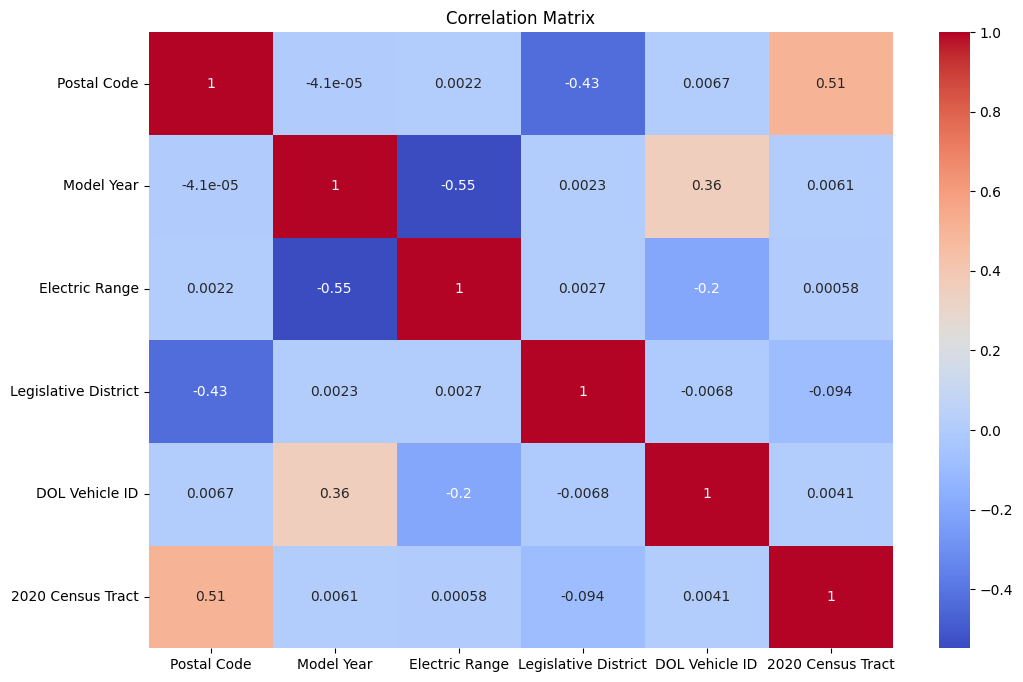

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(EV_df[num_cols].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Data preprocessing

## Data Cleaning

### Missing Value Handling

In [24]:
EV_df.isnull().sum()

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [27]:
#handling numerical missing values in numerical columns
for col in num_cols:
    EV_df[col] = EV_df[col].fillna(EV_df[col].median())

In [28]:
#handling numerical missing values in categorical columns
cat_cols = EV_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    EV_df[col] = EV_df[col].fillna(EV_df[col].mode())

In [29]:
EV_df.isnull().sum() #Checking missing values

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


### Duplicates Removal

In [39]:
#checking duplicates
EV_df.duplicated().sum()

np.int64(0)

In [40]:
#removing duplicates
EV_df = EV_df.drop_duplicates()
print()

## Outlier Handling

###Box plot

In [41]:
#outlier removal:By Using IQR method
for col in num_cols:
    Q1 = EV_df[col].quantile(0.25)
    Q3 = EV_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    EV_df = EV_df[(EV_df[col] >= lower_limit) &(EV_df[col] <= upper_limit)]
print(" outlier removal:", EV_df.shape)

 outlier removal: (138128, 16)


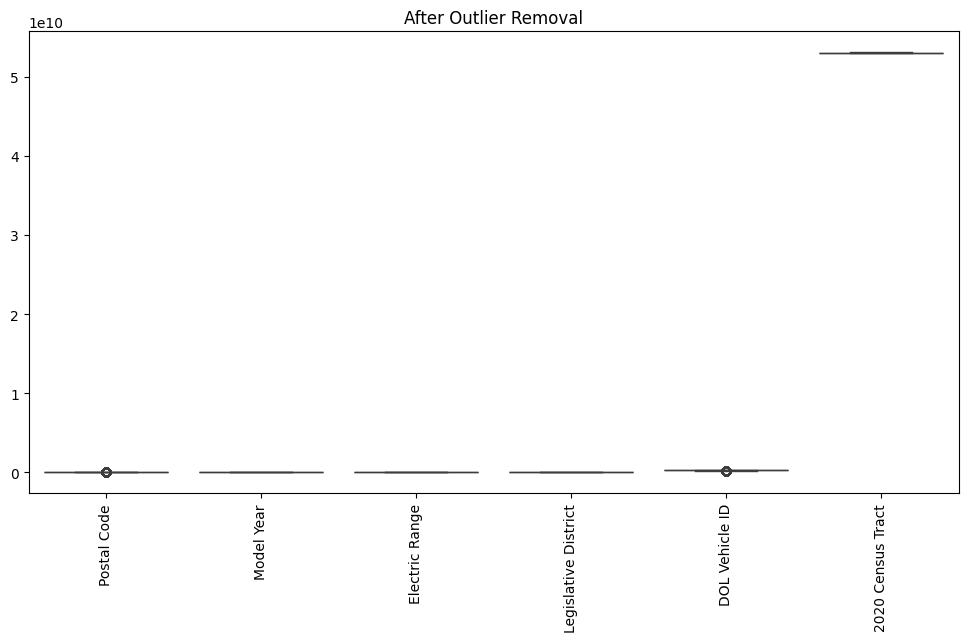

In [42]:
#boxplot after removal of outlier
plt.figure(figsize=(12,6))
sns.boxplot(data=EV_df[num_cols])
plt.xticks(rotation=90)
plt.title("After Outlier Removal")
plt.show()

# Data Transformation

## Scaling

## Encoding

# Data Splitting

# Model Building